In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4, ResNet50V2, DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: []


In [2]:
# Configuration
CONFIG = {
    # Data paths - UPDATE THESE PATHS
    'data_dir': '/path/to/your/ppa_dataset',  # Update this
    'ppa_dir': '/path/to/your/ppa_dataset/ppa',  # Images with PPA
    'no_ppa_dir': '/path/to/your/ppa_dataset/no_ppa',  # Normal images
    
    # Image parameters
    'img_height': 512,
    'img_width': 512,
    'channels': 3,
    
    # Training parameters
    'batch_size': 16,
    'epochs': 50,
    'learning_rate': 1e-4,
    'validation_split': 0.15,
    'test_split': 0.15,
    
    # Model parameters
    'dropout_rate': 0.3,
    'l2_regularization': 0.01,
    
    # Output
    'model_save_path': './models/ppa_detection_model.h5',
    'results_dir': './results/'
}

# Create directories
os.makedirs(os.path.dirname(CONFIG['model_save_path']), exist_ok=True)
os.makedirs(CONFIG['results_dir'], exist_ok=True)

print("Configuration set successfully!")

Configuration set successfully!


In [27]:
def load_image_paths(data_dir, ppa_dir, no_ppa_dir):
    """
    Load image paths and create labels
    """
    image_paths = []
    labels = []
    
    # Load PPA images (label: 1)
    if os.path.exists(ppa_dir):
        for img_name in os.listdir(ppa_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                image_paths.append(os.path.join(ppa_dir, img_name))
                labels.append(1)
    
    # Load No PPA images (label: 0)
    if os.path.exists(no_ppa_dir):
        for img_name in os.listdir(no_ppa_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                image_paths.append(os.path.join(no_ppa_dir, img_name))
                labels.append(0)
    
    return np.array(image_paths), np.array(labels)

# Load data
image_paths, labels = load_image_paths(
    CONFIG['data_dir'], 
    CONFIG['ppa_dir'], 
    CONFIG['no_ppa_dir']
)

print(f"Total images: {len(image_paths)}")
print(f"PPA images: {np.sum(labels == 1)}")
print(f"No PPA images: {np.sum(labels == 0)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 21
PPA images: 8
No PPA images: 13
Class distribution: [13  8]


In [28]:
# PPA Detection - Package Installation and Setup

## STEP 1: Install Required Packages
# Run this cell FIRST before running any other cells

# Copy and paste this into your terminal/command prompt:
"""
pip install numpy pandas matplotlib seaborn opencv-python pillow tensorflow scikit-learn tqdm
"""

# OR run this cell directly in Jupyter:
import sys
import subprocess

def install_packages():
    """Install all required packages"""
    packages = [
        'numpy',
        'pandas', 
        'matplotlib',
        'seaborn',
        'opencv-python',
        'pillow',
        'tensorflow',
        'scikit-learn',
        'tqdm'
    ]
    
    print("Installing required packages...")
    for package in packages:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
            print(f"✓ {package} installed successfully")
        except Exception as e:
            print(f"✗ Error installing {package}: {e}")
    
    print("\nAll packages installed! Please restart the kernel and run the notebook from the beginning.")

# Uncomment the line below to install packages:
# install_packages()

print("To install packages, uncomment the last line and run this cell.")
print("Or run this in your terminal:")
print("pip install numpy pandas matplotlib seaborn opencv-python pillow tensorflow scikit-learn tqdm")

To install packages, uncomment the last line and run this cell.
Or run this in your terminal:
pip install numpy pandas matplotlib seaborn opencv-python pillow tensorflow scikit-learn tqdm


In [15]:
def load_image_paths(data_dir, ppa_dir, no_ppa_dir):
    """
    Load image paths and create labels
    """
    image_paths = []
    labels = []
    
    # Load PPA images (label: 1)
    if os.path.exists(ppa_dir):
        for img_name in os.listdir(ppa_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                image_paths.append(os.path.join(ppa_dir, img_name))
                labels.append(1)
    
    # Load No PPA images (label: 0)
    if os.path.exists(no_ppa_dir):
        for img_name in os.listdir(no_ppa_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                image_paths.append(os.path.join(no_ppa_dir, img_name))
                labels.append(0)
    
    return np.array(image_paths), np.array(labels, dtype=np.int32)  # ← Changed this line

# Load data
image_paths, labels = load_image_paths(
    CONFIG['data_dir'], 
    CONFIG['ppa_dir'], 
    CONFIG['no_ppa_dir']
)

print(f"Total images: {len(image_paths)}")
print(f"PPA images: {np.sum(labels == 1)}")
print(f"No PPA images: {np.sum(labels == 0)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 0
PPA images: 0
No PPA images: 0
Class distribution: []


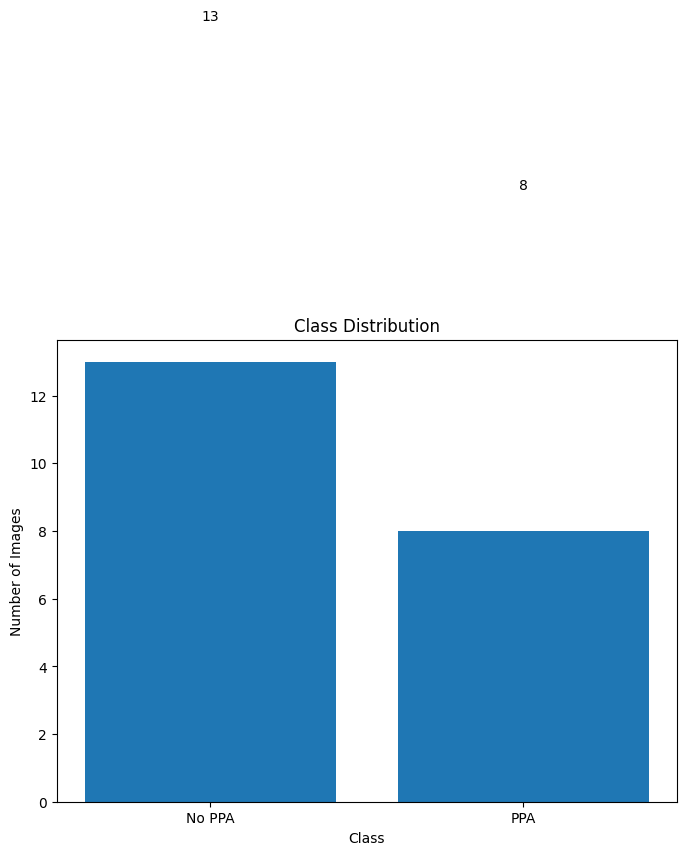

In [29]:
# Visualize class distribution
plt.figure(figsize=(8, 6))
plt.bar(['No PPA', 'PPA'], np.bincount(labels))
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, v in enumerate(np.bincount(labels)):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')
plt.savefig(os.path.join(CONFIG['results_dir'], 'class_distribution.png'))
plt.show()

In [30]:
def preprocess_fundus_image(image_path, target_size=(512, 512)):
    """
    Advanced preprocessing for fundus images
    """
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LANCZOS4)
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # This enhances the local contrast, important for medical images
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    
    return img

def apply_circular_crop(image, center=None, radius_ratio=0.95):
    """
    Apply circular crop to focus on the fundus area
    """
    h, w = image.shape[:2]
    
    if center is None:
        center = (w // 2, h // 2)
    
    radius = int(min(h, w) * radius_ratio / 2)
    
    # Create circular mask
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, center, radius, 255, -1)
    
    # Apply mask
    if len(image.shape) == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    
    masked_image = cv2.bitwise_and(image, mask)
    
    return masked_image

# Test preprocessing on a sample image
if len(image_paths) > 0:
    sample_img = preprocess_fundus_image(image_paths[0])
    print(f"Preprocessed image shape: {sample_img.shape}")
    print(f"Preprocessed image range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")

Preprocessed image shape: (512, 512, 3)
Preprocessed image range: [0.000, 1.000]


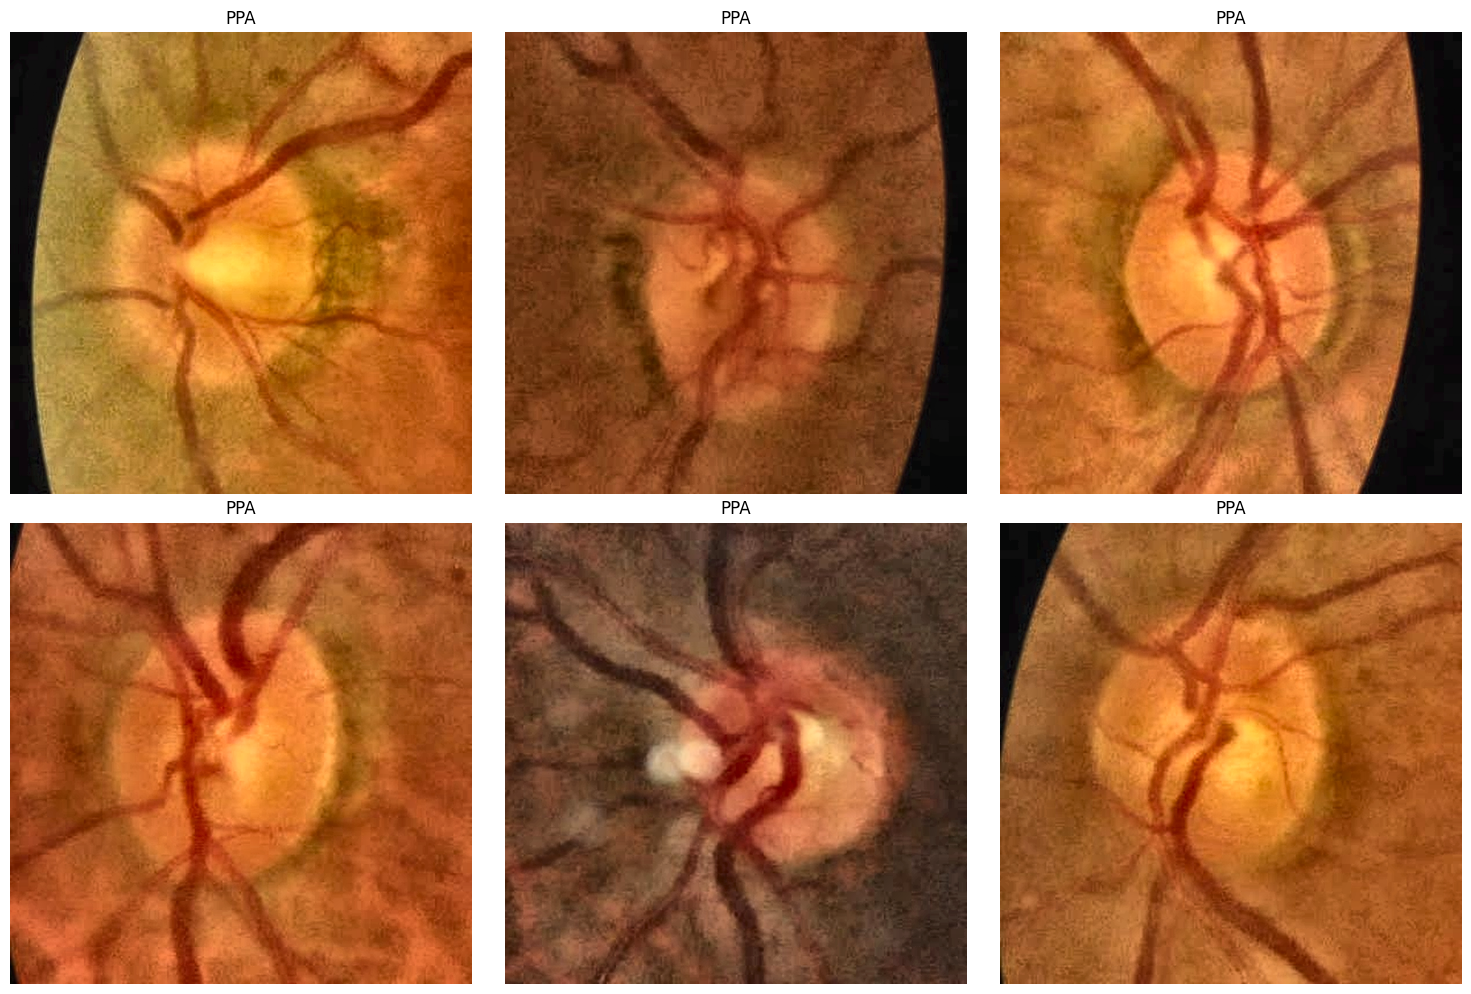

In [31]:
# Visualize preprocessing steps
if len(image_paths) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx in range(min(6, len(image_paths))):
        row = idx // 3
        col = idx % 3
        
        img = preprocess_fundus_image(image_paths[idx])
        label = 'PPA' if labels[idx] == 1 else 'No PPA'
        
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{label}')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['results_dir'], 'sample_images.png'))
    plt.show()

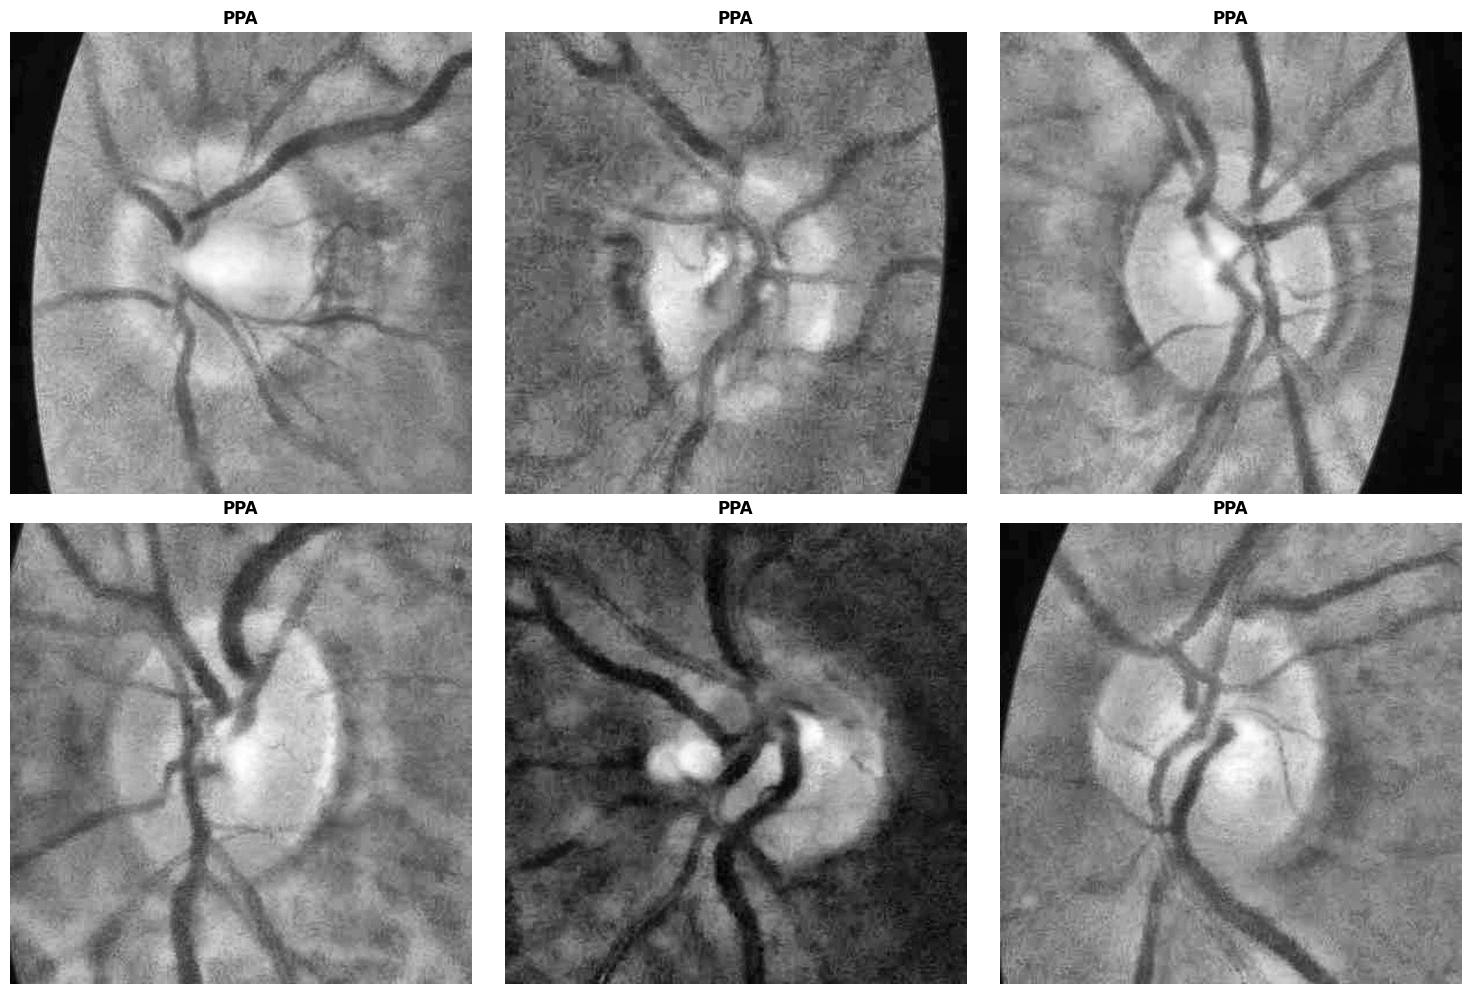

In [43]:
# Visualize preprocessing steps in grayscale
if len(image_paths) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx in range(min(6, len(image_paths))):
        row = idx // 3
        col = idx % 3
        
        img = preprocess_fundus_image(image_paths[idx])
        label = 'PPA' if labels[idx] == 1 else 'No PPA'
        
        # Convert to grayscale for display
        img_gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        
        axes[row, col].imshow(img_gray, cmap='gray')  # Use grayscale colormap
        axes[row, col].set_title(f'{label}', fontsize=12, fontweight='bold')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['results_dir'], 'sample_images.png'))
    plt.show()

In [45]:
# For a more clinical/medical look with inverted colors
axes[row, col].imshow(img_gray, cmap='gray_r')  # Inverted grayscale

# For bone/x-ray look
axes[row, col].imshow(img_gray, cmap='bone')

# For hot/thermal look
axes[row, col].imshow(img_gray, cmap='hot')

In [46]:
# Split data
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=CONFIG['test_split'], 
    stratify=labels, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=CONFIG['validation_split']/(1-CONFIG['test_split']), 
    stratify=y_temp, 
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Validation class distribution: {np.bincount(y_val)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training samples: 14
Validation samples: 3
Test samples: 4

Training class distribution: [9 5]
Validation class distribution: [2 1]
Test class distribution: [2 2]


In [47]:
CONFIG = {
    # Update these paths
    'data_dir': r'C:\Users\ridat\OneDrive\Desktop\ppa',
    'ppa_dir': r'C:\Users\ridat\OneDrive\Desktop\ppa\ppa_present',      # Images WITH PPA
    'no_ppa_dir': r'C:\Users\ridat\OneDrive\Desktop\ppa\ppa_absent',    # Images WITHOUT PPA
    
    # Image parameters
    'img_height': 512,
    'img_width': 512,
    'channels': 3,
    
    # Training parameters
    'batch_size': 16,
    'epochs': 50,
    'learning_rate': 1e-4,
    'validation_split': 0.15,
    'test_split': 0.15,
    
    # Model parameters
    'dropout_rate': 0.3,
    'l2_regularization': 0.01,
    
    # Output
    'model_save_path': './models/ppa_detection_model.h5',
    'results_dir': './results/'
}

In [48]:
# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=CONFIG['test_split'], 
    stratify=labels, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=CONFIG['validation_split']/(1-CONFIG['test_split']), 
    stratify=y_temp, 
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Validation class distribution: {np.bincount(y_val)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training samples: 14
Validation samples: 3
Test samples: 4

Training class distribution: [9 5]
Validation class distribution: [2 1]
Test class distribution: [2 2]


In [49]:
# Custom data generator
class FundusDataGenerator(keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size, target_size, 
                 augmentation=False, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_paths))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_paths = [self.image_paths[k] for k in indexes]
        batch_labels = [self.labels[k] for k in indexes]
        
        X, y = self.__data_generation(batch_paths, batch_labels)
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def __data_generation(self, batch_paths, batch_labels):
        X = np.empty((len(batch_paths), *self.target_size, 3))
        y = np.empty((len(batch_paths),), dtype=int)
        
        for i, (path, label) in enumerate(zip(batch_paths, batch_labels)):
            img = preprocess_fundus_image(path, self.target_size)
            
            if self.augmentation:
                img = self.augment_image(img)
            
            X[i,] = img
            y[i] = label
        
        return X, y
    
    def augment_image(self, img):
        """Apply random augmentations"""
        # Random horizontal flip
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 1)
        
        # Random vertical flip
        if np.random.rand() > 0.5:
            img = cv2.flip(img, 0)
        
        # Random rotation
        if np.random.rand() > 0.5:
            angle = np.random.uniform(-15, 15)
            h, w = img.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h))
        
        # Random brightness adjustment
        if np.random.rand() > 0.5:
            factor = np.random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0, 1)
        
        return img

# Create generators
train_gen = FundusDataGenerator(
    X_train, y_train, 
    CONFIG['batch_size'], 
    (CONFIG['img_height'], CONFIG['img_width']),
    augmentation=True, 
    shuffle=True
)

val_gen = FundusDataGenerator(
    X_val, y_val, 
    CONFIG['batch_size'], 
    (CONFIG['img_height'], CONFIG['img_width']),
    augmentation=False, 
    shuffle=False
)

test_gen = FundusDataGenerator(
    X_test, y_test, 
    CONFIG['batch_size'], 
    (CONFIG['img_height'], CONFIG['img_width']),
    augmentation=False, 
    shuffle=False
)

print("Data generators created successfully!")

Data generators created successfully!


In [50]:
# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=CONFIG['test_split'], 
    stratify=labels, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=CONFIG['validation_split']/(1-CONFIG['test_split']), 
    stratify=y_temp, 
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Validation class distribution: {np.bincount(y_val)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training samples: 14
Validation samples: 3
Test samples: 4

Training class distribution: [9 5]
Validation class distribution: [2 1]
Test class distribution: [2 2]


In [51]:
# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=CONFIG['test_split'], 
    stratify=labels, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=CONFIG['validation_split']/(1-CONFIG['test_split']), 
    stratify=y_temp, 
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Validation class distribution: {np.bincount(y_val)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training samples: 14
Validation samples: 3
Test samples: 4

Training class distribution: [9 5]
Validation class distribution: [2 1]
Test class distribution: [2 2]


In [52]:
# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, 
    test_size=CONFIG['test_split'], 
    stratify=labels, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=CONFIG['validation_split']/(1-CONFIG['test_split']), 
    stratify=y_temp, 
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Validation class distribution: {np.bincount(y_val)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training samples: 14
Validation samples: 3
Test samples: 4

Training class distribution: [9 5]
Validation class distribution: [2 1]
Test class distribution: [2 2]


In [54]:
# DIAGNOSTIC CELL - Run this to check your data
print("="*60)
print("DATA LOADING DIAGNOSTIC")
print("="*60)
print(f"\nCurrent working directory: {os.getcwd()}")
print(f"\nCONFIG paths:")
print(f"  data_dir: {CONFIG['data_dir']}")
print(f"  ppa_dir: {CONFIG['ppa_dir']}")
print(f"  no_ppa_dir: {CONFIG['no_ppa_dir']}")
print(f"\nDirectory existence check:")
print(f"  ppa_dir exists: {os.path.exists(CONFIG['ppa_dir'])}")
print(f"  no_ppa_dir exists: {os.path.exists(CONFIG['no_ppa_dir'])}")
if os.path.exists(CONFIG['ppa_dir']):
    ppa_files = os.listdir(CONFIG['ppa_dir'])
    print(f"\nFiles in ppa_dir: {len(ppa_files)} total")
    image_files = [f for f in ppa_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    print(f"  Image files: {len(image_files)}")
    if len(image_files) > 0:
        print(f"  Sample files: {image_files[:3]}")
else:
    print(f"\n❌ PPA directory does not exist: {CONFIG['ppa_dir']}")
if os.path.exists(CONFIG['no_ppa_dir']):
    no_ppa_files = os.listdir(CONFIG['no_ppa_dir'])
    print(f"\nFiles in no_ppa_dir: {len(no_ppa_files)} total")
    image_files = [f for f in no_ppa_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    print(f"  Image files: {len(image_files)}")
    if len(image_files) > 0:
        print(f"  Sample files: {image_files[:3]}")
else:
    print(f"\n❌ No PPA directory does not exist: {CONFIG['no_ppa_dir']}")
print(f"\nLoaded data:")
print(f"  Total images: {len(image_paths)}")
print(f"  PPA images: {np.sum(labels == 1)}")
print(f"  No PPA images: {np.sum(labels == 0)}")
print("\n" + "="*60)
print("NEXT STEPS:")
print("="*60)
if len(image_paths) == 0:
    print("❌ No images loaded! Please:")
    print("1. Check that your directory paths are correct")
    print("2. Make sure the directories contain image files")
    print("3. Update CONFIG['ppa_dir'] and CONFIG['no_ppa_dir'] with correct paths")
    print("\nExample (use raw strings with r''):")
    print(r"  CONFIG['ppa_dir'] = r'C:\Users\ridat\OneDrive\Desktop\ppa\ppa_present'")
    print(r"  CONFIG['no_ppa_dir'] = r'C:\Users\ridat\OneDrive\Desktop\ppa\ppa_absent'")
else:
    print(f"✅ Successfully loaded {len(image_paths)} images!")

DATA LOADING DIAGNOSTIC

Current working directory: C:\Users\ridat\OneDrive\Desktop\ppa

CONFIG paths:
  data_dir: C:\Users\ridat\OneDrive\Desktop\ppa
  ppa_dir: C:\Users\ridat\OneDrive\Desktop\ppa\ppa_present
  no_ppa_dir: C:\Users\ridat\OneDrive\Desktop\ppa\ppa_absent

Directory existence check:
  ppa_dir exists: True
  no_ppa_dir exists: True

Files in ppa_dir: 8 total
  Image files: 8
  Sample files: ['18.jpg', '23.jpg', '24.jpg']

Files in no_ppa_dir: 13 total
  Image files: 13
  Sample files: ['1.jpg', '12.jpg', '13.jpg']

Loaded data:
  Total images: 21
  PPA images: 8
  No PPA images: 13

NEXT STEPS:
✅ Successfully loaded 21 images!


In [55]:
def build_efficientnet_model(input_shape=(512, 512, 3), dropout_rate=0.3):
    """
    EfficientNetB4-based model (Recommended for PPA detection)
    Best balance of accuracy and efficiency
    """
    base_model = EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    
    # Freeze early layers, fine-tune later layers
    for layer in base_model.layers[:-50]:
        layer.trainable = False
    
    # Build model
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu', 
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name='EfficientNetB4_PPA')
    return model

def build_resnet_model(input_shape=(512, 512, 3), dropout_rate=0.3):
    """
    ResNet50V2-based model
    Good for fine-grained feature detection
    """
    base_model = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name='ResNet50V2_PPA')
    return model

def build_custom_cnn(input_shape=(512, 512, 3), dropout_rate=0.3):
    """
    Custom CNN architecture for PPA detection
    Lightweight alternative for smaller datasets
    """
    inputs = keras.Input(shape=input_shape)
    
    # Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)
    
    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)
    
    # Global pooling and dense layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name='Custom_CNN_PPA')
    return model

# Build model (change function to try different architectures)
model = build_efficientnet_model(
    input_shape=(CONFIG['img_height'], CONFIG['img_width'], 3),
    dropout_rate=CONFIG['dropout_rate']
)

model.summary()

Model: "EfficientNetB4_PPA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 512, 512, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb4 (Functional)          │ (None, 1792)                │      17,673,823 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1792)                │           7,168 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1792)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         459,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,156,512 (69.26 MB)

 Trainable params: 6,915,385 (26.38 MB)

 Non-trainable params: 11,241,127 (42.88 MB)

In [21]:
CONFIG = {
    # Update these paths - use raw strings (r'') for Windows paths
    'data_dir': r'C:\Users\ridat\OneDrive\Desktop\ppa',
    'ppa_dir': r'C:\Users\ridat\OneDrive\Desktop\ppa\ppa_present',
    'no_ppa_dir': r'C:\Users\ridat\OneDrive\Desktop\ppa\ppa_absent',
    
    # Image parameters
    'img_height': 512,
    'img_width': 512,
    'channels': 3,
    
    # Training parameters
    'batch_size': 16,
    'epochs': 50,
    'learning_rate': 1e-4,
    'validation_split': 0.15,
    'test_split': 0.15,
    
    # Model parameters
    'dropout_rate': 0.3,
    'l2_regularization': 0.01,
    
    # Output
    'model_save_path': './models/ppa_detection_model.h5',
    'results_dir': './results/'
}

In [6]:
# Calculate class weights for imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(f"Class weights: {class_weight_dict}")

# Compile model
model.compile(
    optimizer=Adam(learning_rate=CONFIG['learning_rate']),
    loss=BinaryCrossentropy(),
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

# Callbacks
callbacks = [
    ModelCheckpoint(
        CONFIG['model_save_path'],
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    TensorBoard(
        log_dir='./logs',
        histogram_freq=1
    )
]

print("Model compiled successfully!")

NameError: name 'y_train' is not defined

In [7]:
# Train model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining completed!")

NameError: name 'train_gen' is not defined

NameError: name 'history' is not defined

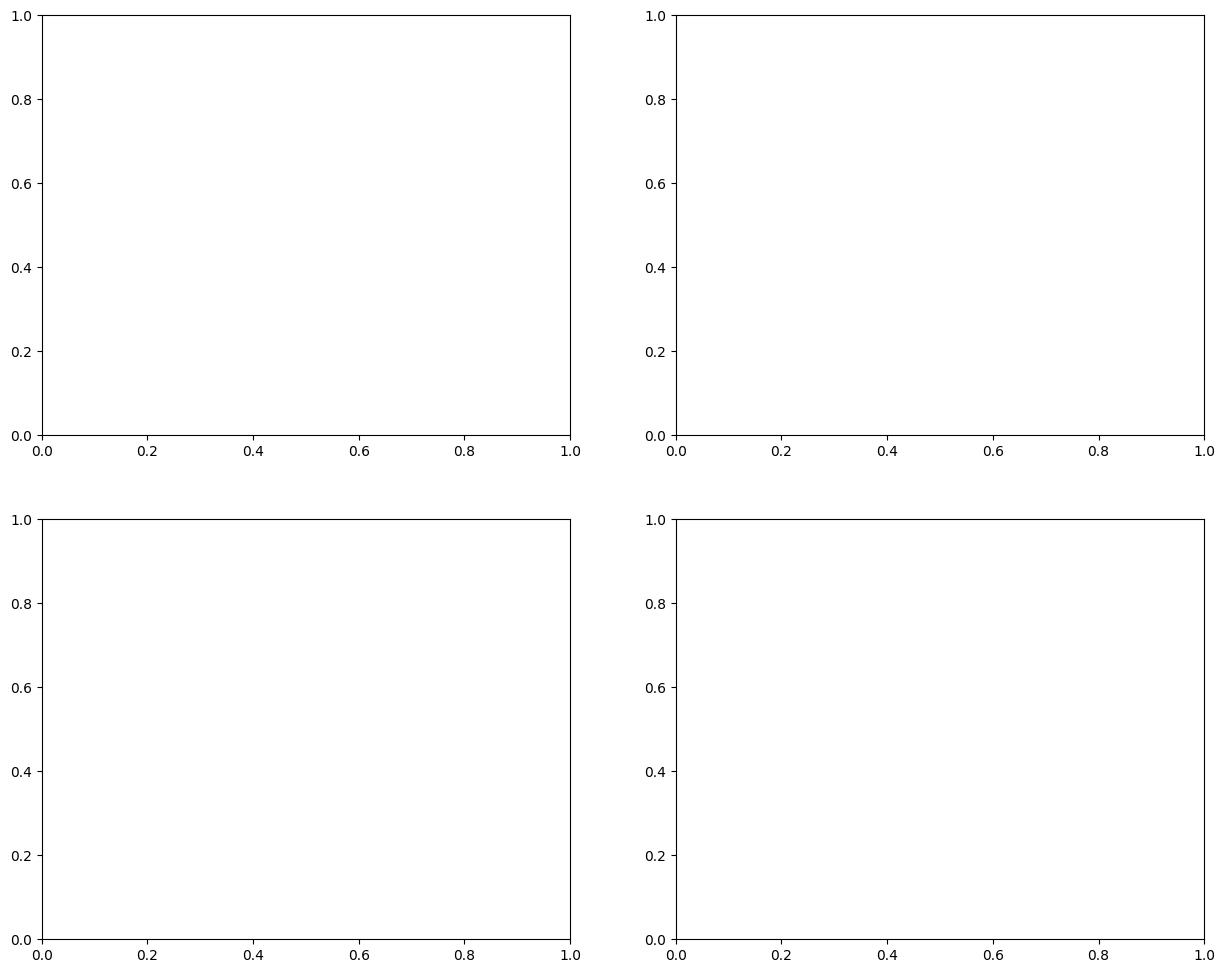

In [8]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss')
axes[0, 1].plot(history.history['val_loss'], label='Val Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train AUC')
axes[1, 0].plot(history.history['val_auc'], label='Val AUC')
axes[1, 0].set_title('Model AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Precision & Recall
axes[1, 1].plot(history.history['precision'], label='Train Precision')
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_precision'], label='Val Precision')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Precision & Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'training_history.png'), dpi=300)
plt.show()

In [9]:
# Load best model
best_model = keras.models.load_model(CONFIG['model_save_path'])

# Evaluate on test set
test_results = best_model.evaluate(test_gen, verbose=1)

print("\n=== Test Set Results ===")
for metric_name, value in zip(best_model.metrics_names, test_results):
    print(f"{metric_name}: {value:.4f}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = './models/ppa_detection_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [10]:
# Generate predictions
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No PPA', 'PPA']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No PPA', 'PPA'],
            yticklabels=['No PPA', 'PPA'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(CONFIG['results_dir'], 'confusion_matrix.png'), dpi=300)
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - PPA Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(CONFIG['results_dir'], 'roc_curve.png'), dpi=300)
plt.show()

NameError: name 'best_model' is not defined

In [11]:
# Visualize predictions on test set
num_samples = min(12, len(X_test))
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, sample_idx in enumerate(sample_indices):
    img = preprocess_fundus_image(X_test[sample_idx])
    true_label = 'PPA' if y_test[sample_idx] == 1 else 'No PPA'
    pred_label = 'PPA' if y_pred[sample_idx] == 1 else 'No PPA'
    confidence = y_pred_proba[sample_idx][0]
    
    color = 'green' if y_pred[sample_idx] == y_test[sample_idx] else 'red'
    
    axes[idx].imshow(img)
    axes[idx].set_title(
        f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}',
        color=color, fontweight='bold'
    )
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'predictions_visualization.png'), dpi=300)
plt.show()

NameError: name 'X_test' is not defined

In [12]:
def predict_ppa(image_path, model, threshold=0.5):
    """
    Predict PPA for a single image
    """
    # Preprocess image
    img = preprocess_fundus_image(
        image_path, 
        target_size=(CONFIG['img_height'], CONFIG['img_width'])
    )
    
    # Add batch dimension
    img_batch = np.expand_dims(img, axis=0)
    
    # Predict
    prediction = model.predict(img_batch, verbose=0)[0][0]
    
    # Determine class
    predicted_class = 'PPA' if prediction > threshold else 'No PPA'
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(f'Prediction: {predicted_class}\nConfidence: {prediction:.4f}')
    plt.axis('off')
    plt.show()
    
    return {
        'prediction': predicted_class,
        'confidence': float(prediction),
        'ppa_probability': float(prediction),
        'no_ppa_probability': float(1 - prediction)
    }

# Example usage
if len(X_test) > 0:
    sample_path = X_test[0]
    result = predict_ppa(sample_path, best_model)
    print("\nPrediction Result:")
    for key, value in result.items():
        print(f"{key}: {value}")

NameError: name 'X_test' is not defined

In [13]:
# Save model in different formats
best_model.save('./models/ppa_detection_full_model.keras')
print("Model saved in Keras format")

# Save as TFLite for mobile deployment
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()
with open('./models/ppa_detection_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model saved in TFLite format")

# Save configuration and results
results_summary = {
    'model_architecture': best_model.name,
    'test_accuracy': float(test_results[1]),
    'test_precision': float(test_results[2]),
    'test_recall': float(test_results[3]),
    'test_auc': float(test_results[4]),
    'roc_auc': float(roc_auc),
    'training_samples': len(X_train),
    'validation_samples': len(X_val),
    'test_samples': len(X_test),
    'config': CONFIG
}

import json
with open('./results/model_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

print("\n=== Final Model Summary ===")
print(json.dumps(results_summary, indent=2, default=str))

NameError: name 'best_model' is not defined

In [14]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for model interpretability
    """
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Note: You'll need to identify the last convolutional layer name
# For EfficientNet, it's typically 'top_conv'
# For ResNet, it's typically the last conv block
# Uncomment and modify based on your chosen architecture

# last_conv_layer_name = 'top_conv'  # Adjust based on model
# sample_img_path = X_test[0]
# img = preprocess_fundus_image(sample_img_path)
# img_array = np.expand_dims(img, axis=0)
# heatmap = make_gradcam_heatmap(img_array, best_model, last_conv_layer_name)

print("Grad-CAM visualization function defined (uncomment to use)")

Grad-CAM visualization function defined (uncomment to use)
